# Applied AI & ML Capstone Project

## Part 2 – Supervised Machine Learning Model

### Objective

The objective of this notebook is to build and evaluate both regression and classification models using the cleaned Ames Housing dataset. The workflow includes preprocessing, feature encoding, scaling, model training, evaluation, regularization, ROC analysis, threshold tuning, and bootstrap confidence interval estimation.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    LogisticRegression
)

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

## Load Cleaned Dataset

In [3]:
df = pd.read_csv("cleaned_data.csv")

display(df.head())

print(df.shape)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


(2930, 82)


## Define Regression and Classification Targets

In [4]:
# Regression Target
y_reg = df["SalePrice"]

# Classification Target
y_clf = (y_reg > y_reg.median()).astype(int)

# Features
X = df.drop(columns=["SalePrice"])

print("Regression Target Shape:", y_reg.shape)
print("Classification Balance:")
print(y_clf.value_counts())

Regression Target Shape: (2930,)
Classification Balance:
SalePrice
0    1467
1    1463
Name: count, dtype: int64


## Define Features and Target Variables

For the regression task, the target variable is **SalePrice**, which represents the continuous house sale price.

For the classification task, a binary target variable is created by comparing each house price with the median SalePrice. Houses with prices above the median are assigned class 1, while houses below or equal to the median are assigned class 0.

All remaining columns are treated as input features.

In [5]:
# Regression target

y_reg = df["SalePrice"]


# Classification target
y_clf = (y_reg > y_reg.median()).astype(int)


# Feature matrix
X = df.drop(columns=["SalePrice"])


print("Features shape:", X.shape)

print("\nRegression Target:")
display(y_reg.head())

print("\nClassification Target Distribution:")
print(y_clf.value_counts())

Features shape: (2930, 81)

Regression Target:


0    215000
1    105000
2    172000
3    244000
4    189900
Name: SalePrice, dtype: int64


Classification Target Distribution:
SalePrice
0    1467
1    1463
Name: count, dtype: int64


## Encode Categorical Features

One-hot encoding is applied to categorical variables to convert them into numerical form.

In [7]:
# Identify categorical columns

categorical_cols = X.select_dtypes(
    include="object"
).columns


# Apply one-hot encoding

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)


# Convert boolean columns

X = X.astype(float)


print("Shape after encoding:", X.shape)

Shape after encoding: (2930, 262)


## Train-Test Split and Feature Scaling

Data is split before scaling to prevent data leakage.

In [8]:
# Split regression data

X_train_reg, X_test_reg, y_reg_train, y_reg_test = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)


# Scale features

scaler = StandardScaler()

X_train_reg_scaled = scaler.fit_transform(
    X_train_reg
)

X_test_reg_scaled = scaler.transform(
    X_test_reg
)


print("Training shape:", X_train_reg_scaled.shape)
print("Testing shape:", X_test_reg_scaled.shape)

Training shape: (2344, 262)
Testing shape: (586, 262)


## Linear Regression Model

Train a Linear Regression model to predict the continuous target variable `SalePrice`.

In [9]:
# Initialize and train Linear Regression model

lr_model = LinearRegression()

lr_model.fit(
    X_train_reg_scaled,
    y_reg_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](262,)","[ -761.27, 1955.44,-2435.36,..., 548.55, 3450.73, 1448.12]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.786e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,262
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(257)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](262,)","[193.19,133.82,116.89,..., 0. , 0. , 0. ]"


## Regression Prediction and Evaluation

The model performance is evaluated using:
- Mean Squared Error (MSE)
- R² Score

In [10]:
# Predict on test data

y_pred_reg = lr_model.predict(
    X_test_reg_scaled
)


# Evaluation metrics

lr_mse = mean_squared_error(
    y_reg_test,
    y_pred_reg
)

lr_r2 = r2_score(
    y_reg_test,
    y_pred_reg
)


print("Linear Regression Results")
print("-------------------------")
print("MSE:", lr_mse)
print("R² Score:", lr_r2)

Linear Regression Results
-------------------------
MSE: 834182322.2214195
R² Score: 0.8959554305867465


## Linear Regression Coefficient Analysis

Coefficients show the relationship between features and predicted SalePrice.

In [11]:
# Create coefficient dataframe

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})


# Add absolute coefficient values

coef_df["Absolute_Coefficient"] = abs(
    coef_df["Coefficient"]
)


# Sort by importance

coef_df_sorted = coef_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)


coef_df_sorted.head(10)

,Feature,Coefficient,Absolute_Coefficient
10,BsmtFin SF 1,133328.896107,133328.896107
12,Bsmt Unf SF,120065.284955,120065.284955
13,Total Bsmt SF,-112078.084464,112078.084464
118,Roof Matl_CompShg,76279.598126,76279.598126
122,Roof Matl_Tar&Grv,55233.285634,55233.285634
11,BsmtFin SF 2,49325.332637,49325.332637
123,Roof Matl_WdShake,36665.525285,36665.525285
124,Roof Matl_WdShngl,35271.413160,35271.413160
231,Garage Qual_TA,-23409.535425,23409.535425
235,Garage Cond_TA,17621.921515,17621.921515


## Top Three Important Features

The three features with the highest absolute coefficient values are considered the most influential features in the Linear Regression model.

In [12]:
# Top 3 features

top_features = coef_df_sorted.head(3)

top_features

,Feature,Coefficient,Absolute_Coefficient
10,BsmtFin SF 1,133328.896107,133328.896107
12,Bsmt Unf SF,120065.284955,120065.284955
13,Total Bsmt SF,-112078.084464,112078.084464


## Ridge Regression Model

Ridge Regression applies L2 regularization to reduce overfitting and control large coefficients.

In [13]:
# Initialize Ridge model

ridge_model = Ridge(
    alpha=1.0
)


# Train model

ridge_model.fit(
    X_train_reg_scaled,
    y_reg_train
)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [14]:
# Predictions

y_pred_ridge = ridge_model.predict(
    X_test_reg_scaled
)


# Metrics

ridge_mse = mean_squared_error(
    y_reg_test,
    y_pred_ridge
)


ridge_r2 = r2_score(
    y_reg_test,
    y_pred_ridge
)


print("Ridge Regression Results")
print("-------------------------")
print("MSE:", ridge_mse)
print("R² Score:", ridge_r2)

Ridge Regression Results
-------------------------
MSE: 829823305.0624026
R² Score: 0.8964991151641986


## Linear Regression vs Ridge Regression Comparison

In [15]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression"
    ],
    "MSE": [
        lr_mse,
        ridge_mse
    ],
    "R2 Score": [
        lr_r2,
        ridge_r2
    ]
})


comparison

,Model,MSE,R2 Score
0,Linear Regression,8.341823e+08,0.895955
1,Ridge Regression,8.298233e+08,0.896499


## Logistic Regression Classification

The regression target `SalePrice` is converted into a binary classification problem:
- 0 → SalePrice below or equal to median
- 1 → SalePrice above median

A Logistic Regression model is trained to classify houses into these two categories.

In [16]:
# Split data for classification

X_train_clf, X_test_clf, y_clf_train, y_clf_test = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42
)


print("Training data:", X_train_clf.shape)
print("Testing data:", X_test_clf.shape)

Training data: (2344, 262)
Testing data: (586, 262)


## Check Class Distribution

The class distribution is checked to identify any imbalance before training.

In [17]:
print("Training class distribution:")
print(y_clf_train.value_counts())


print("\nClass percentage:")
print(y_clf_train.value_counts(normalize=True) * 100)

Training class distribution:
SalePrice
0    1186
1    1158
Name: count, dtype: int64

Class percentage:
SalePrice
0    50.59727
1    49.40273
Name: proportion, dtype: float64


## Feature Scaling for Classification

The scaler is fitted only on training data to prevent data leakage.

In [18]:
# Scale classification features

scaler_clf = StandardScaler()


X_train_clf_scaled = scaler_clf.fit_transform(
    X_train_clf
)


X_test_clf_scaled = scaler_clf.transform(
    X_test_clf
)


print("Scaling completed")

Scaling completed


## Train Logistic Regression Model

The model uses max_iter=1000 to allow sufficient iterations for convergence.

In [19]:
# Initialize Logistic Regression

log_model = LogisticRegression(
    max_iter=1000
)


# Train model

log_model.fit(
    X_train_clf_scaled,
    y_clf_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

## Model Predictions and Evaluation

The model performance is evaluated using:
- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1-score

In [20]:
# Predict class labels

y_pred_clf = log_model.predict(
    X_test_clf_scaled
)


# Predict probabilities for ROC curve

y_prob_clf = log_model.predict_proba(
    X_test_clf_scaled
)[:,1]


print("Confusion Matrix:")
print(confusion_matrix(
    y_clf_test,
    y_pred_clf
))


print("\nClassification Report:")
print(classification_report(
    y_clf_test,
    y_pred_clf
))

Confusion Matrix:
[[264  17]
 [ 22 283]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       281
           1       0.94      0.93      0.94       305

    accuracy                           0.93       586
   macro avg       0.93      0.93      0.93       586
weighted avg       0.93      0.93      0.93       586



In [21]:
accuracy = accuracy_score(
    y_clf_test,
    y_pred_clf
)

precision = precision_score(
    y_clf_test,
    y_pred_clf
)

recall = recall_score(
    y_clf_test,
    y_pred_clf
)

f1 = f1_score(
    y_clf_test,
    y_pred_clf
)


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

NameError: name 'accuracy_score' is not defined

## ROC Curve and AUC Score

The ROC curve shows the model's ability to separate the two classes across different thresholds.

AUC Score: 0.9792077475059798


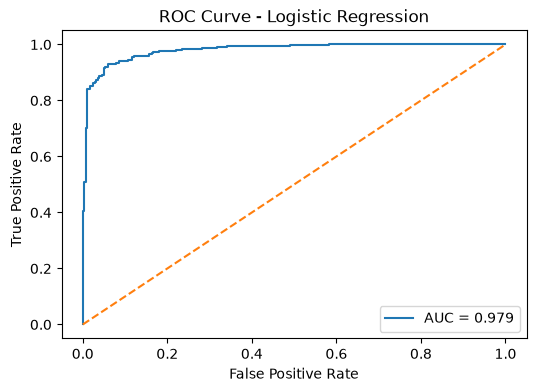

In [22]:
# Calculate ROC values

fpr, tpr, thresholds = roc_curve(
    y_clf_test,
    y_prob_clf
)


# Calculate AUC

auc_score = roc_auc_score(
    y_clf_test,
    y_prob_clf
)


print("AUC Score:", auc_score)


# Plot ROC curve

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()
plt.show()

## Decision Threshold Sensitivity Analysis

The default classification threshold of 0.5 is adjusted to evaluate how different thresholds affect precision, recall, and F1-score.

In [23]:
# Threshold values

thresholds = np.arange(
    0.30,
    0.71,
    0.10
)


results = []


# Test different thresholds

for threshold in thresholds:
    
    # Convert probabilities into class predictions
    
    y_threshold_pred = (
        y_prob_clf >= threshold
    ).astype(int)
    
    
    precision = precision_score(
        y_clf_test,
        y_threshold_pred
    )
    
    
    recall = recall_score(
        y_clf_test,
        y_threshold_pred
    )
    
    
    f1 = f1_score(
        y_clf_test,
        y_threshold_pred
    )
    
    
    results.append([
        threshold,
        precision,
        recall,
        f1
    ])


# Create dataframe

threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)


threshold_df

,Threshold,Precision,Recall,F1
0,0.3,0.897516,0.947541,0.921850
1,0.4,0.919872,0.940984,0.930308
2,0.5,0.943333,0.927869,0.935537
3,0.6,0.952055,0.911475,0.931323
4,0.7,0.957597,0.888525,0.921769


## Best F1 Score Threshold

The threshold with the highest F1-score is selected as the optimal threshold for this dataset.

In [24]:
best_threshold = threshold_df.loc[
    threshold_df["F1"].idxmax()
]


best_threshold

Threshold    0.500000
Precision    0.943333
Recall       0.927869
F1           0.935537
Name: 2, dtype: float64

## Threshold Interpretation

Precision measures the correctness of positive predictions, while recall measures how many actual positive cases are identified.

Increasing the threshold generally increases precision but decreases recall. Lowering the threshold improves recall but may increase false positives.

## Logistic Regression Regularization Experiment

A second Logistic Regression model is trained with stronger L2 regularization (`C=0.01`) and compared against the baseline model (`C=1.0`).

In [25]:
# Logistic Regression with default regularization

log_model_c1 = LogisticRegression(
    C=1.0,
    max_iter=1000
)


log_model_c1.fit(
    X_train_clf_scaled,
    y_clf_train
)


# Predictions

y_pred_c1 = log_model_c1.predict(
    X_test_clf_scaled
)


y_prob_c1 = log_model_c1.predict_proba(
    X_test_clf_scaled
)[:,1]

In [26]:
# Logistic Regression with stronger regularization

log_model_c001 = LogisticRegression(
    C=0.01,
    max_iter=1000
)


log_model_c001.fit(
    X_train_clf_scaled,
    y_clf_train
)


# Predictions

y_pred_c001 = log_model_c001.predict(
    X_test_clf_scaled
)


y_prob_c001 = log_model_c001.predict_proba(
    X_test_clf_scaled
)[:,1]

## Compare Regularization Performance

The models are compared using precision, recall, and AUC score.

In [27]:
comparison_reg = pd.DataFrame({

    "Model": [
        "Logistic Regression (C=1.0)",
        "Logistic Regression (C=0.01)"
    ],

    "Precision": [
        precision_score(y_clf_test, y_pred_c1),
        precision_score(y_clf_test, y_pred_c001)
    ],

    "Recall": [
        recall_score(y_clf_test, y_pred_c1),
        recall_score(y_clf_test, y_pred_c001)
    ],

    "AUC": [
        roc_auc_score(y_clf_test, y_prob_c1),
        roc_auc_score(y_clf_test, y_prob_c001)
    ]

})


comparison_reg

,Model,Precision,Recall,AUC
0,Logistic Regression (C=1.0),0.943333,0.927869,0.979208
1,Logistic Regression (C=0.01),0.963087,0.940984,0.990736


## Bootstrap Confidence Interval for AUC Difference

Bootstrap sampling is used to estimate how consistently the C=1.0 Logistic Regression model performs better than the C=0.01 model.

The AUC difference is calculated as:

AUC(C=1.0) - AUC(C=0.01)

In [28]:
# Store AUC differences

auc_differences = []


# Number of bootstrap samples

n_bootstrap = 500


# Bootstrap process

for i in range(n_bootstrap):

    # Sample indices with replacement
    
    indices = np.random.choice(
        len(y_clf_test),
        size=len(y_clf_test),
        replace=True
    )


    # Select bootstrap samples
    
    y_true_sample = y_clf_test.iloc[indices]

    prob_c1_sample = y_prob_c1[indices]

    prob_c001_sample = y_prob_c001[indices]


    # Calculate AUC difference
    
    auc_c1 = roc_auc_score(
        y_true_sample,
        prob_c1_sample
    )


    auc_c001 = roc_auc_score(
        y_true_sample,
        prob_c001_sample
    )


    difference = auc_c1 - auc_c001


    auc_differences.append(
        difference
    )


print("Bootstrap samples completed:", len(auc_differences))

Bootstrap samples completed: 500


## Bootstrap Confidence Interval Results

In [29]:
# Calculate confidence interval

mean_difference = np.mean(
    auc_differences
)


lower_bound = np.percentile(
    auc_differences,
    2.5
)


upper_bound = np.percentile(
    auc_differences,
    97.5
)


print("Mean AUC Difference:", mean_difference)

print("95% Confidence Interval:")
print(
    lower_bound,
    "to",
    upper_bound
)

Mean AUC Difference: -0.011564676306780769
95% Confidence Interval:
-0.01964576491572741 to -0.0054716968695282175


## Interpretation

If the confidence interval does not include zero, the performance difference between the two models is likely consistent across different samples.

If it includes zero, the difference may not be statistically reliable.